# 04. Consumption Spike & Anomaly Detection
Here we implement a scoring system and detect abnormal consumption behavior to alert utility managers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
df = pd.read_csv("../Dataset/processed/water_consumption_processed.csv")
df["date"] = pd.to_datetime(df["date"])

## 1. Z-Score Based Anomaly Detection
We identify instances where usage significantly deviates from the 7-day rolling mean.

In [3]:
df["z_score"] = (df["consumption_liters"] - df["rolling_mean_7"]) / df["rolling_std_7"]
threshold_std = 2.0

df["is_anomaly"] = (df["z_score"].abs() > threshold_std).astype(int)
df["anomaly_type"] = "Normal"
df.loc[(df["is_anomaly"]==1) & (df["z_score"]>0), "anomaly_type"] = "Spike"
df.loc[(df["is_anomaly"]==1) & (df["z_score"]<0), "anomaly_type"] = "Drop"

print("Anomalies Detected:")
display(df["anomaly_type"].value_counts())

Anomalies Detected:


anomaly_type
Normal    794
Drop       41
Spike      30
Name: count, dtype: int64

## 2. Visualize Anomalies for a Region

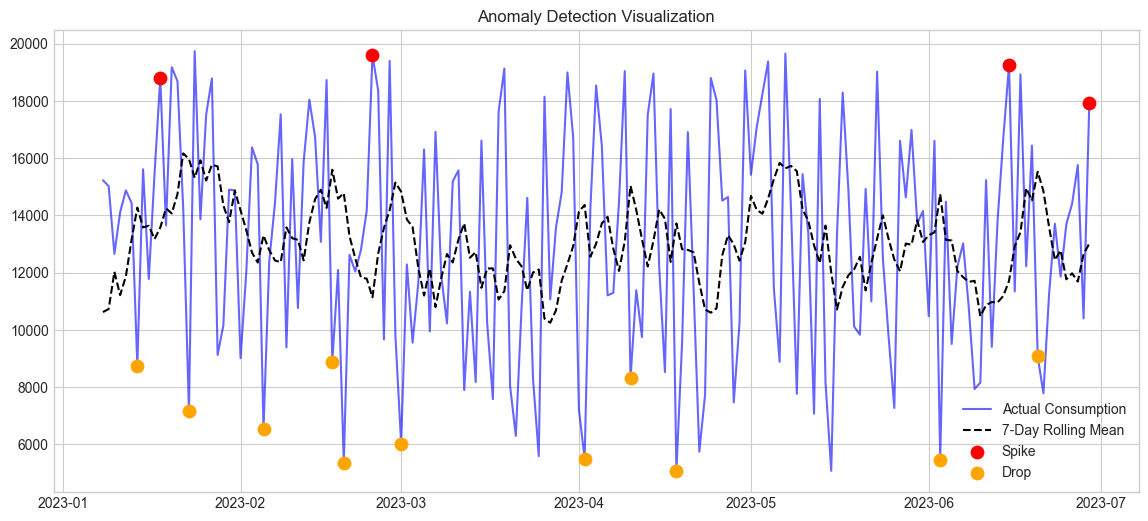

In [4]:
region_df = df[df["region"] == df["region"].unique()[0]]
plt.figure(figsize=(14,6))
plt.plot(region_df["date"], region_df["consumption_liters"], label="Actual Consumption", color="blue", alpha=0.6)
plt.plot(region_df["date"], region_df["rolling_mean_7"], label="7-Day Rolling Mean", color="black", linestyle="--")

spikes = region_df[region_df["anomaly_type"] == "Spike"]
drops = region_df[region_df["anomaly_type"] == "Drop"]

plt.scatter(spikes["date"], spikes["consumption_liters"], color="red", label="Spike", zorder=5, s=80)
plt.scatter(drops["date"], drops["consumption_liters"], color="orange", label="Drop", zorder=5, s=80)

plt.title("Anomaly Detection Visualization")
plt.legend()
plt.show()

## 3. Demand Categorization
We categorize overall demand into Low, Medium, and High bands.

In [5]:
low_thresh = df["consumption_liters"].quantile(0.33)
high_thresh = df["consumption_liters"].quantile(0.67)

def categorize(val):
    if val < low_thresh: return "Low"
    elif val > high_thresh: return "High"
    else: return "Medium"

df["demand_category"] = df["consumption_liters"].apply(categorize)
print("Demand Category Distribution:")
display(df["demand_category"].value_counts())

Demand Category Distribution:


demand_category
Medium    293
High      286
Low       286
Name: count, dtype: int64